# EDA — Healthcare Dataset

Notebook phân tích dữ liệu bệnh viện synthetic (`healthcare_dataset.csv`, 55.500 dòng × 15 cột).

## Các bước EDA

1. [Load dữ liệu và kiểm tra kích thước](#1-load-dữ-liệu-và-kiểm-tra-kích-thước)
2. [Xử lý giá trị thiếu](#2-xử-lý-giá-trị-thiếu-missing-values)
3. [Kiểm tra và xử lý ngoại lệ](#3-kiểm-tra-và-xử-lý-dữ-liệu-ngoại-lệ-outlier)
4. [Kiểm tra phân phối dữ liệu](#4-kiểm-tra-phân-phối-dữ-liệu)
5. [Kiểm tra mối quan hệ giữa các biến](#5-kiểm-tra-mối-quan-hệ-giữa-các-biến)
6. [Feature engineering](#6-feature-engineering-tạo-đặc-trưng-mới)
7. [Tổng kết](#7-tổng-kết)


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.offline as pyo 
import plotly.io as pio
import sklearn
import plotly.express as ex

import warnings
warnings.filterwarnings('ignore')

In [107]:
from pathlib import Path

candidates = [
    Path("healthcare_dataset.csv"),
    Path("/kaggle/input/healthcare-dataset/healthcare_dataset.csv"),
]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "healthcare_dataset.csv not found. Place it next to this notebook "
        "or keep the Kaggle input path."
    )

df = pd.read_csv(csv_path)
df.head().T

,0,1,2,3,4
Name,Bobby JacksOn,LesLie TErRy,DaNnY sMitH,andrEw waTtS,adrIENNE bEll
Age,30,62,76,28,43
Gender,Male,Male,Female,Female,Female
Blood Type,B-,A+,A-,O+,AB+
Medical Condition,Cancer,Obesity,Obesity,Diabetes,Cancer
Date of Admission,2024-01-31,2019-08-20,2022-09-22,2020-11-18,2022-09-19
Doctor,Matthew Smith,Samantha Davies,Tiffany Mitchell,Kevin Wells,Kathleen Hanna
Hospital,Sons and Miller,Kim Inc,Cook PLC,"Hernandez Rogers and Vang,",White-White
Insurance Provider,Blue Cross,Medicare,Aetna,Medicare,Aetna
Billing Amount,18856.281306,33643.327287,27955.096079,37909.78241,14238.317814


## 1. Load dữ liệu và kiểm tra kích thước

Đọc CSV (local hoặc path Kaggle), rồi kiểm tra kích thước và tên cột.

- `df.shape` — số dòng, số cột
- `df.columns` — tên cột
- `df.head()` — vài hàng đầu


In [108]:
print("số dòng, số cột: ", df.shape)
print("tên các cột: ", df.columns.tolist())

số dòng, số cột:  (55500, 15)
tên các cột:  ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


## 2. Xử lý giá trị thiếu (missing values)

### 2.1. Kiểm tra missing

- `df.isnull().sum()` — đếm số ô trống từng cột



In [109]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


### 2.2. Cách xử lý giá trị thiếu

- Xóa dòng/cột thiếu nhiều: `df.dropna()`
- Điền mean/median — **chỉ cột số**: `df.fillna(df.mean(numeric_only=True))`
- Cột chữ: điền mode (giá trị xuất hiện nhiều nhất)
- Nâng cao: dùng model để dự đoán giá trị thiếu

`df.mean()` không có `numeric_only=True` sẽ lỗi vì không tính trung bình được cột chữ (`Name`, `Gender`, ...).


In [127]:
df = df.fillna(df.mean(numeric_only=True))
print(df.isnull().sum())

Name                      0
Age                       0
Gender                    0
Blood Type                0
Medical Condition         0
Date of Admission         0
Doctor                    0
Hospital                  0
Insurance Provider        0
Billing Amount            0
Room Number               0
Admission Type            0
Discharge Date            0
Medication                0
Test Results              0
Age_minmax                0
Age_standard              0
Admission_Year            0
Admission_Month           0
Admission_Day             0
Admission_DayOfWeek       0
Length_of_Stay            0
Admission_Type_encoded    0
Test_Results_encoded      0
dtype: int64


In [111]:
# inplace=True: sửa df tại chỗ, hàm trả về None
# không dùng inplace (rõ hơn): df = df.fillna(...)
# nên viết: df = df.fillna(df.mean(numeric_only=True))

## 3. Kiểm tra và xử lý dữ liệu ngoại lệ (outlier)

### 3.1. Kiểm tra giá trị ngoại lệ

- IQR hoặc Z-score để phát hiện outlier
- Vẽ boxplot: `sns.boxplot()` — chấm ngoài râu là ngoại lệ


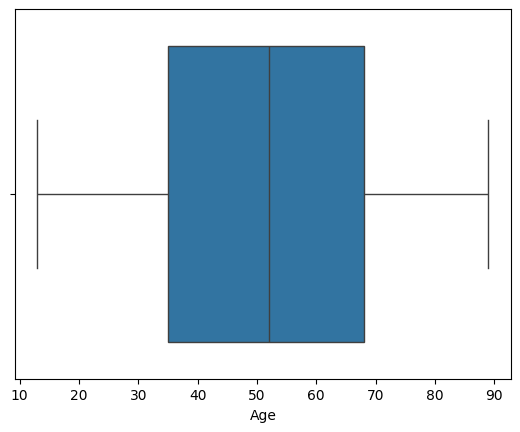

In [112]:
sns.boxplot(x=df['Age'])
plt.show()


### 3.2. Xử lý giá trị ngoại lệ

- Loại bỏ bằng IQR: giữ giá trị trong `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`
- Winsorization: không xóa dòng, chỉ cắt giá trị về ngưỡng (`clip`)


In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
# df = df[df['Age'] < Q3 + 1.5 * IQR]
# df = df[df['Age'] > Q1 - 1.5 * IQR]

df= df[(df['Age'] < Q3 + 1.5 * IQR) & (df['Age'] > Q1 - 1.5 * IQR)]
df.shape

(55500, 15)

In [128]:
# Winsorization: không xóa dòng, chỉ cắt giá trị vượt ngưỡng về cận dưới/trên
# Cách 1: ngưỡng IQR (cùng Q1, Q3, IQR ở cell trên — đang là của Age)
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Age_winsor'] = df['Age'].clip(lower=lower, upper=upper)


In [129]:
# Cách 2: cắt theo phân vị 1%–99% (hay dùng, ít phụ thuộc outlier)
low_bill = df['Billing Amount'].quantile(0.01)
high_bill = df['Billing Amount'].quantile(0.99)
df['Billing_winsor'] = df['Billing Amount'].clip(lower=low_bill, upper=high_bill)


In [131]:

print('ngưỡng Age IQR:', lower, upper)
print('ngưỡng Billing 1%–99%:', low_bill, high_bill)
print('số dòng không đổi:', len(df))


ngưỡng Age IQR: -14.5 117.5
ngưỡng Billing 1%–99%: 1225.7863283252464 49848.11793557254
số dòng không đổi: 55500


In [132]:
df[['Age', 'Age_winsor', 'Billing Amount', 'Billing_winsor']].describe()


,Age,Age_winsor,Billing Amount,Billing_winsor
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,51.539459,25539.316097,25540.038948
std,19.602454,19.602454,14211.454431,14187.312114
min,13.000000,13.000000,-2008.492140,1225.786328
25%,35.000000,35.000000,13241.224652,13241.224652
50%,52.000000,52.000000,25538.069376,25538.069376
75%,68.000000,68.000000,37820.508436,37820.508436
max,89.000000,89.000000,52764.276736,49848.117936


## 4. Kiểm tra phân phối dữ liệu

Xem dữ liệu tập trung ở đâu, có lệch không, các nhóm có cân bằng không.

### 4.1. Kiểm tra kiểu dữ liệu

- `df.info()` — số dòng, kiểu cột (`int`, `float`, `object`), số ô non-null


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

#### Nhận xét sau `df.info()`

- Cột ngày đang là `object` (chữ) → bước 6 đổi sang datetime
- Cột chữ (`Name`, `Gender`, ...) cần encode trước khi đưa vào model
- Dataset đủ 55.500 dòng, không thiếu dữ liệu


### 4.2. Phân phối biến số

- Histogram / KDE: xem hình dạng (lệch, 1 đỉnh hay 2 đỉnh)
- `df.describe()`: count, mean, std, min, Q1, median, Q3, max


                Age  Billing Amount
count  55500.000000    55500.000000
mean      51.539459    25539.316097
std       19.602454    14211.454431
min       13.000000    -2008.492140
25%       35.000000    13241.224652
50%       52.000000    25538.069376
75%       68.000000    37820.508436
max       89.000000    52764.276736


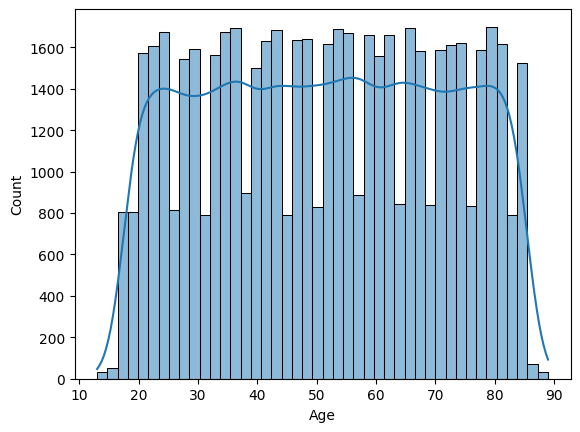

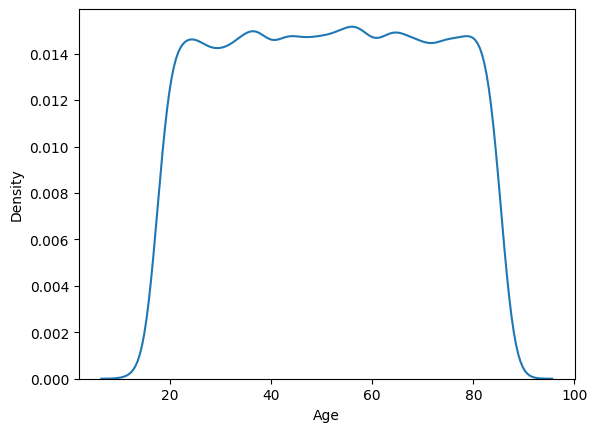

In [115]:
print(df[['Age', 'Billing Amount']].describe())

sns.histplot(df['Age'], kde=True)
plt.show()

sns.kdeplot(df['Age'])
plt.show()


### 4.3. Phân phối biến danh mục

- `value_counts()` — tần suất từng nhóm
- Dataset này các nhóm gần cân bằng (`Gender` ~ 50/50, `Admission Type` ~ 1/3)


In [116]:
print(df['Gender'].value_counts())


Gender
Male      27774
Female    27726
Name: count, dtype: int64


## 5. Kiểm tra mối quan hệ giữa các biến

Xem các cột có liên quan nhau không (ví dụ tuổi ↔ viện phí). Tên, ID, số phòng thường không liên quan bệnh.

### 5.1. Tương quan giữa biến số

- Ma trận tương quan `df.corr()` + heatmap
- Chỉ tính trên cột số: `numeric_only=True` (không thì lỗi cột chữ)
- Dataset synthetic này: `Age`, `Billing Amount`, `Room Number` gần như không tương quan (hệ số ≈ 0) — bình thường


In [117]:
corr = df.corr(numeric_only=True)
corr

,Age,Billing Amount,Room Number
Age,1.000000,-0.003832,-0.000720
Billing Amount,-0.003832,1.000000,-0.002943
Room Number,-0.000720,-0.002943,1.000000


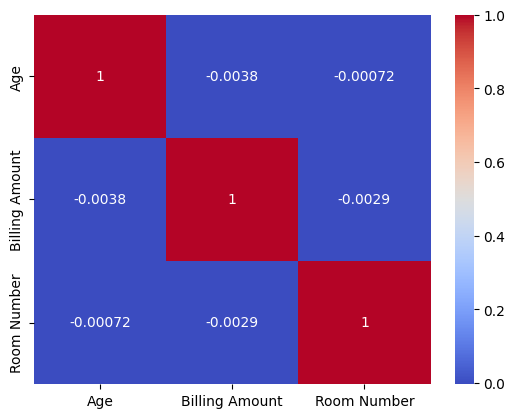

In [118]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#### Cách đọc heatmap

`sns.heatmap(corr, annot=True, cmap='coolwarm')`

- `annot=True` — viết số hệ số tương quan lên từng ô (`False` = chỉ màu)
- `cmap='coolwarm'` — đỏ = tương quan dương, xanh = âm, gần trắng ≈ 0

Dataset này hệ số gần 0 nên heatmap gần như một màu nhạt — bình thường với data synthetic.


### 5.2. Mối quan hệ giữa biến phân loại và biến số

- Dùng boxplot hoặc violin plot
- Cần **1 cột phân loại (ít nhóm)** + **1 cột số**

#### Cột số (trục Y)

| Cột | Nên dùng? | Lý do |
|---|---|---|
| `Age` | Có | tuổi bệnh nhân, ý nghĩa rõ |
| `Billing Amount` | Có | tiền viện phí, so sánh theo nhóm rất hợp |
| `Room Number` | Không | số phòng, không phải đại lượng thống kê |

#### Cột phân loại (trục X)

Chỉ lấy cột ít nhóm.

| Cột | Số nhóm | Nên dùng? |
|---|---|---|
| `Gender` | 2 | Tốt nhất, dễ đọc |
| `Admission Type` | 3 | Tốt (`Elective`, `Urgent`, `Emergency`) |
| `Test Results` | 3 | Tốt (`Normal`, `Abnormal`, `Inconclusive`) |
| `Medical Condition` | 6 | Tốt |
| `Insurance Provider` | 5 | Tốt |
| `Medication` | 5 | Tốt |
| `Blood Type` | 8 | Dùng được, hơi nhiều nhóm |
| `Name`, `Doctor`, `Hospital` | hàng chục nghìn | **Không** — boxplot sẽ rối |
| `Date of Admission`, `Discharge Date` | hàng nghìn ngày | **Không** — không phải category |


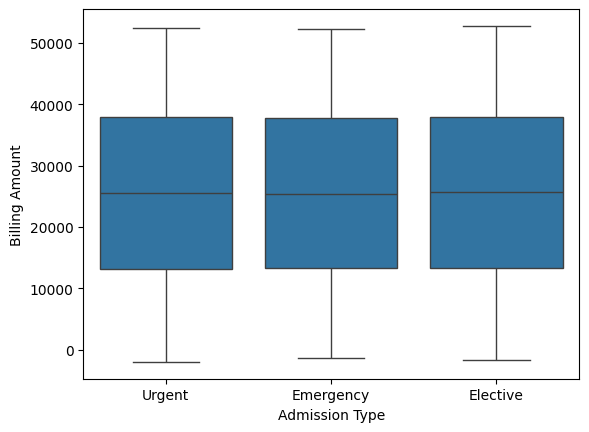

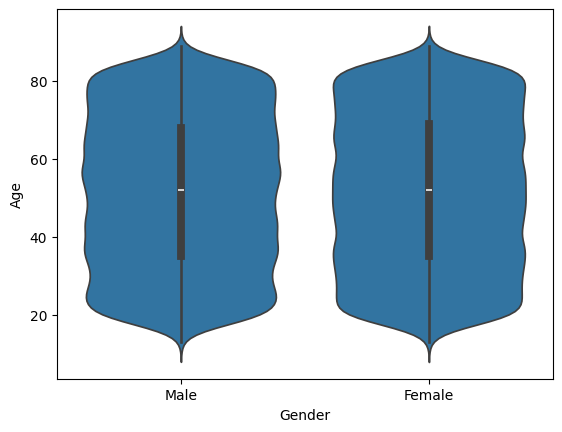

In [119]:
sns.boxplot(x="Admission Type", y="Billing Amount", data=df)
plt.show()

sns.violinplot(x="Gender", y="Age", data=df)
plt.show()

#### Ý nghĩa boxplot

Boxplot tóm tắt phân phối của biến số trong từng nhóm bằng 5 số:

- **min / max** (hoặc râu): khoảng giá trị chính
- **Q1, Q3 (hộp)**: 50% dữ liệu nằm trong hộp (IQR)
- **median (vạch giữa hộp)**: giá trị điển hình của nhóm
- **chấm ngoài râu**: outlier

Dùng để so sánh nhanh: nhóm nào cao/thấp hơn, nhóm nào phân tán hơn, nhóm nào có ngoại lệ.

Ví dụ: `Admission Type` × `Billing Amount` — viện phí cấp cứu, khẩn, chủ động khác nhau không.

#### Ý nghĩa violin plot

Violin plot = boxplot + mật độ phân phối. Mỗi “cây đàn” là một nhóm:

- **Bề ngang (mập/ốm):** chỗ mập = nhiều người ở giá trị đó; chỗ thon = ít người
- **Chiều cao:** min → max của nhóm
- **Bên trong:** thường có boxplot nhỏ (median, IQR)

Dùng khi muốn thấy dữ liệu tập trung ở đâu, có lệch trái/phải, hay có 2 đỉnh (bimodal).

Ví dụ: `Gender` × `Age` — nam/nữ phân bố tuổi thế nào, không chỉ median.

#### Khác nhau giữa boxplot và violin plot

| | Boxplot | Violin plot |
|---|---|---|
| Cho biết | min, Q1, median, Q3, max, outlier | những cái đó **và** hình dạng phân phối |
| Có thấy 2 đỉnh không? | Không | Có (bimodal) |
| Khi nào dùng | Nhanh, dễ đọc | Muốn xem phân phối có lệch, có 2 cụm |


## 6. Feature engineering (tạo đặc trưng mới)

Model chỉ hiểu số. Cột chữ và cột ngày phải biến đổi trước khi train.

### 6.1. Biến đổi dữ liệu số và thời gian

- Chuẩn hoá (MinMax / StandardScaler): đưa cột số về cùng thang đo
- Thời gian: tách năm, tháng, ngày, số ngày nằm viện


In [120]:
# MinMaxScaler: đưa Age về [0, 1]
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
df['Age_minmax'] = minmax.fit_transform(df[['Age']])
df[['Age', 'Age_minmax']].head()



,Age,Age_minmax
0,30,0.223684
1,62,0.644737
2,76,0.828947
3,28,0.197368
4,43,0.394737


In [121]:
# StandardScaler: mean ≈ 0, std ≈ 1 (không ghi đè Age_minmax)
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()
df['Age_standard'] = standard.fit_transform(df[['Age']])
df[['Age', 'Age_minmax', 'Age_standard']].head()


,Age,Age_minmax,Age_standard
0,30,0.223684,-1.098824
1,62,0.644737,0.533639
2,76,0.828947,1.247842
3,28,0.197368,-1.200853
4,43,0.394737,-0.435636


#### MinMaxScaler vs StandardScaler

Cả hai đều đổi thang đo của cột số. Ở đây đang scale `Age` (13 → 89).

##### MinMaxScaler (normalization)

Đưa về khoảng **[0, 1]**:

```
x_scaled = (x - min) / (max - min)
```

| Age gốc | Age_minmax |
|---|---|
| 13 (min) | 0.0 |
| 51 (gần mean) | ~0.50 |
| 89 (max) | 1.0 |

- Giữ hình dạng phân phối (chỉ kéo giãn)
- Nhạy outlier: một giá trị cực lớn kéo max lên, các giá trị khác bị dồn gần 0

##### StandardScaler (standardization)

Đưa về **mean ≈ 0, std ≈ 1** (z-score):

```
x_scaled = (x - mean) / std
```

Với `Age` (mean ≈ 51.5, std ≈ 19.6):

| Age gốc | Age_standard |
|---|---|
| 13 | ≈ -1.96 |
| 51.5 | ≈ 0 |
| 89 | ≈ +1.91 |

- Không bị kẹt trong [0, 1], có số âm
- Ít bị outlier kéo hơn MinMax
- Phù hợp SVM, PCA, K-Means, hồi quy, neural net

##### Bảng so sánh

| | MinMaxScaler | StandardScaler |
|---|---|---|
| Công thức | `(x − min) / (max − min)` | `(x − mean) / std` |
| Kết quả | thường **0 → 1** | **mean 0, std 1** (có số âm) |
| Ý nghĩa 0 | giá trị **nhỏ nhất** | giá trị **trung bình** |
| Outlier | rất nhạy | ít nhạy hơn |
| Khi nào dùng | cần biên độ cố định (ảnh, khoảng cách, NN [0,1]) | hầu hết ML dạng số (SVM, PCA, hồi quy) |

##### Nên dùng thế nào

Với bộ healthcare này (`Age` + `Billing Amount`):

- **Mặc định `StandardScaler`** nếu làm SVM, Logistic Regression, K-Means, PCA, KNN, neural net
- **`MinMaxScaler`** khi model cần input 0–1
- **Không scale** nếu dùng cây: Decision Tree, Random Forest, XGBoost
- Chỉ scale cột số có ý nghĩa: `Age`, `Billing Amount`. Không scale `Room Number` và cột chữ
- `Billing Amount` có số âm, trải rộng → StandardScaler ổn định hơn

Cách dùng đúng (tránh data leakage):

```python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'Billing Amount']
X_train, X_test = train_test_split(df[num_cols], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # học mean/std từ TRAIN
X_test_scaled = scaler.transform(X_test)         # chỉ transform TEST
```

- `fit` = học min/max hoặc mean/std
- `transform` = áp dụng công thức đã học
- `fit_transform` = làm cả hai, **chỉ dùng cho train**


#### Biến đổi dữ liệu thời gian (date/time features)

Cột ngày dạng chữ (`2024-01-31`) model không dùng được. Phải `pd.to_datetime` rồi tách thành số:

- `.dt.year` — năm
- `.dt.month` — tháng (1–12)
- `.dt.day` — ngày trong tháng
- `.dt.dayofweek` — thứ trong tuần (0 = Thứ 2)
- trừ 2 ngày → số ngày nằm viện (`Length_of_Stay`)

Dataset này dùng được: `Date of Admission`, `Discharge Date`.


In [122]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Admission_Year'] = df['Date of Admission'].dt.year
df['Admission_Month'] = df['Date of Admission'].dt.month
df['Admission_Day'] = df['Date of Admission'].dt.day
df['Admission_DayOfWeek'] = df['Date of Admission'].dt.dayofweek
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df[['Date of Admission', 'Admission_Year', 'Admission_Month', 'Admission_Day', 'Admission_DayOfWeek', 'Length_of_Stay']].head()


,Date of Admission,Admission_Year,Admission_Month,Admission_Day,Admission_DayOfWeek,Length_of_Stay
0,2024-01-31,2024,1,31,2,2
1,2019-08-20,2019,8,20,1,6
2,2022-09-22,2022,9,22,3,15
3,2020-11-18,2020,11,18,2,30
4,2022-09-19,2022,9,19,0,20


### 6.2. Mã hoá biến phân loại (Encoding)

Model không hiểu chữ (`Male`, `Urgent`). Phải đổi thành số.

- **One-hot encoding** (`pd.get_dummies()`): biến **không có thứ tự**
  - Dataset này: `Gender`, `Blood Type`, `Medical Condition`, `Insurance Provider`, `Medication`, `Test Results`
- **Label encoding**: mỗi nhóm 1 số 0, 1, 2, …
  - Làm tay `.map()` khi biến **có thứ tự** — `Admission Type` (Elective < Urgent < Emergency)
  - Làm bằng hàm `LabelEncoder` khi không cần tự chọn thứ tự, hoặc cho **cột target**

Không encode: `Name`, `Doctor`, `Hospital` (quá nhiều giá trị).


In [123]:
# One-hot encoding: biến không có thứ tự (Gender)
# mỗi nhóm thành 1 cột 0/1, ví dụ Gender_Female, Gender_Male
# mỗi giá trị khác nhau là 1 cột mới
df_onehot = pd.get_dummies(df[['Gender', 'Test Results']], dtype=int)
df_onehot.head()


,Gender_Female,Gender_Male,Test Results_Abnormal,Test Results_Inconclusive,Test Results_Normal
0,0,1,0,0,1
1,0,1,0,1,0
2,1,0,0,0,1
3,1,0,1,0,0
4,1,0,1,0,0


In [124]:
# Làm tay: tự map để giữ thứ tự Elective < Urgent < Emergency
admission_order = {'Elective': 0, 'Urgent': 1, 'Emergency': 2}
df['Admission_Type_encoded'] = df['Admission Type'].map(admission_order)
df[['Admission Type', 'Admission_Type_encoded']].head()


,Admission Type,Admission_Type_encoded
0,Urgent,1
1,Emergency,2
2,Emergency,2
3,Elective,0
4,Urgent,1


In [125]:
# Làm bằng hàm: LabelEncoder tự gán 0,1,2 theo alphabet (A→Z)
# Abnormal=0, Inconclusive=1, Normal=2 — không theo ý nghĩa y khoa
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Test_Results_encoded'] = le.fit_transform(df['Test Results'])
df[['Test Results', 'Test_Results_encoded']].head()


,Test Results,Test_Results_encoded
0,Normal,2
1,Inconclusive,1
2,Normal,2
3,Abnormal,0
4,Abnormal,0


In [126]:
df[['Admission Type', 'Admission_Type_encoded', 'Test Results', 'Test_Results_encoded']].head()


,Admission Type,Admission_Type_encoded,Test Results,Test_Results_encoded
0,Urgent,1,Normal,2
1,Emergency,2,Inconclusive,1
2,Emergency,2,Normal,2
3,Elective,0,Abnormal,0
4,Urgent,1,Abnormal,0


## 7. Tổng kết

Sau các bước trên, dataset sạch hơn và có thêm đặc trưng để đưa vào mô hình ML.


